# Part 1 — Data Loading & EDA

# Walmart Sales Forecasting
End-to-end pipeline: EDA â†’ Feature Engineering â†’ Prophet â†’ XGBoost â†’ Final Validation

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import os

# Download dataset
path = kagglehub.dataset_download("aslanahmedov/walmart-sales-forecast")

features_df = pd.read_csv(os.path.join(path, "features.csv"))
stores_df   = pd.read_csv(os.path.join(path, "stores.csv"))
train_df    = pd.read_csv(os.path.join(path, "train.csv"))
test_df     = pd.read_csv(os.path.join(path, "test.csv"))

print("features_df:", features_df.shape)
print("stores_df  :", stores_df.shape)
print("train_df   :", train_df.shape)
print("test_df    :", test_df.shape)

features_df: (8190, 12)
stores_df  : (45, 3)
train_df   : (421570, 5)
test_df    : (115064, 4)


## Data Preprocessing

In [4]:
# Drop MarkDown columns (>60% missing, low predictive value)
features_df = features_df.drop(
    columns=["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
)

# Parse dates
train_df["Date"]    = pd.to_datetime(train_df["Date"])
features_df["Date"] = pd.to_datetime(features_df["Date"])

# Merge all data sources
df = train_df.merge(features_df, on=["Store", "Date", "IsHoliday"], how="left")
df = df.merge(stores_df, on="Store", how="left")
df = df.sort_values("Date").reset_index(drop=True)

print("Merged shape:", df.shape)
df.head()

Merged shape: (421570, 11)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,A,151315
1,29,5,2010-02-05,15552.08,False,24.36,2.788,131.527903,10.064,B,93638
2,29,6,2010-02-05,3200.22,False,24.36,2.788,131.527903,10.064,B,93638
3,29,7,2010-02-05,10820.05,False,24.36,2.788,131.527903,10.064,B,93638
4,29,8,2010-02-05,20055.64,False,24.36,2.788,131.527903,10.064,B,93638


## Exploratory Data Analysis

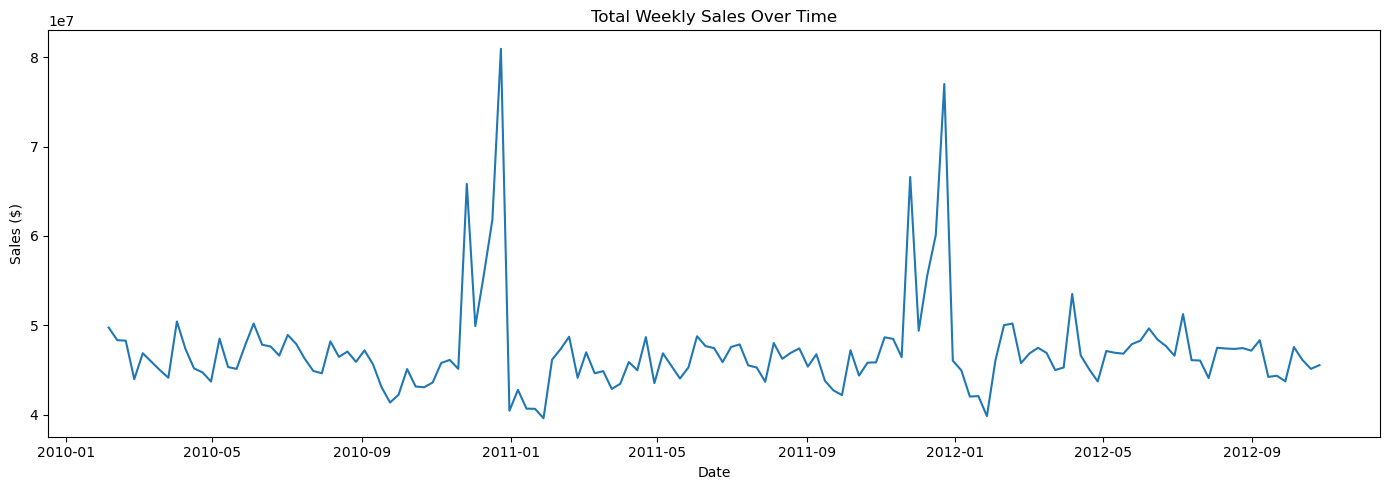

In [6]:
weekly_sales = df.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize=(14, 5))
plt.plot(weekly_sales)
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.show()

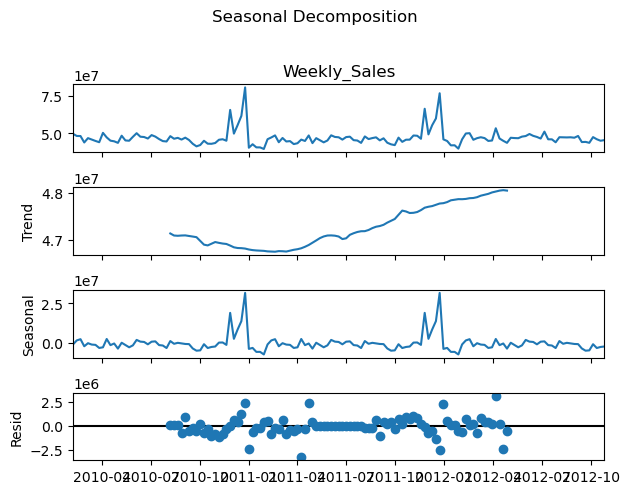

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(weekly_sales, model="additive", period=52)
decomposition.plot()
plt.suptitle("Seasonal Decomposition", y=1.02)
plt.tight_layout()
plt.show()

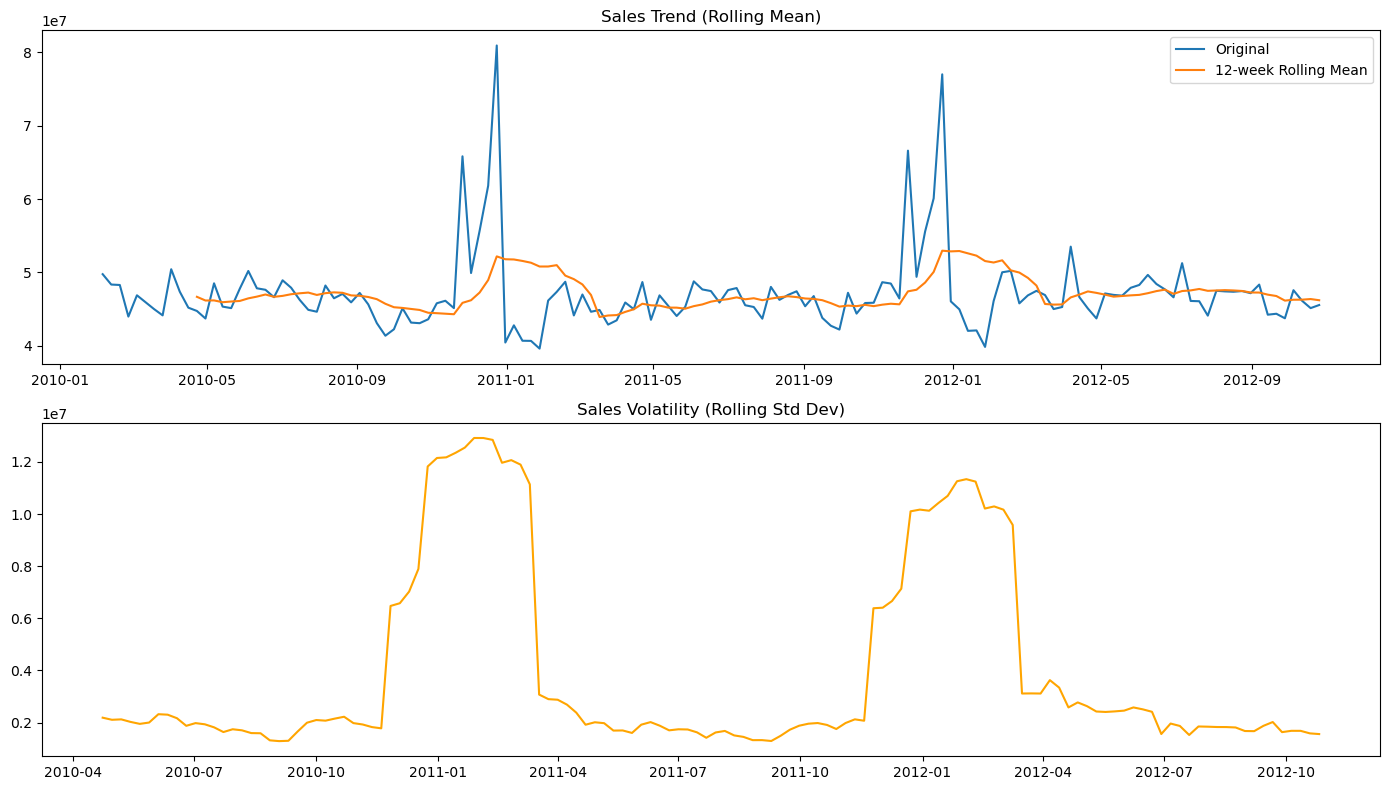

In [8]:
weekly_sales_df = weekly_sales.to_frame()
weekly_sales_df["Rolling_Mean"] = weekly_sales_df["Weekly_Sales"].rolling(window=12).mean()
weekly_sales_df["Rolling_STD"]  = weekly_sales_df["Weekly_Sales"].rolling(window=12).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(weekly_sales_df["Weekly_Sales"], label="Original")
axes[0].plot(weekly_sales_df["Rolling_Mean"], label="12-week Rolling Mean")
axes[0].set_title("Sales Trend (Rolling Mean)")
axes[0].legend()

axes[1].plot(weekly_sales_df["Rolling_STD"], color="orange")
axes[1].set_title("Sales Volatility (Rolling Std Dev)")

plt.tight_layout()
plt.show()

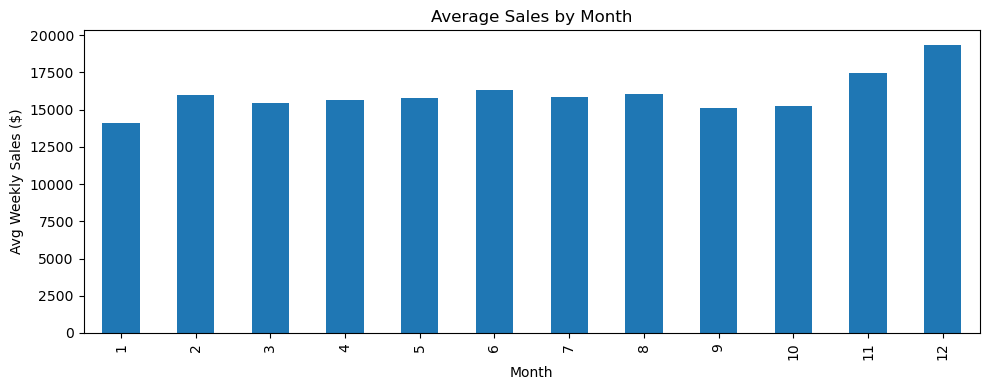

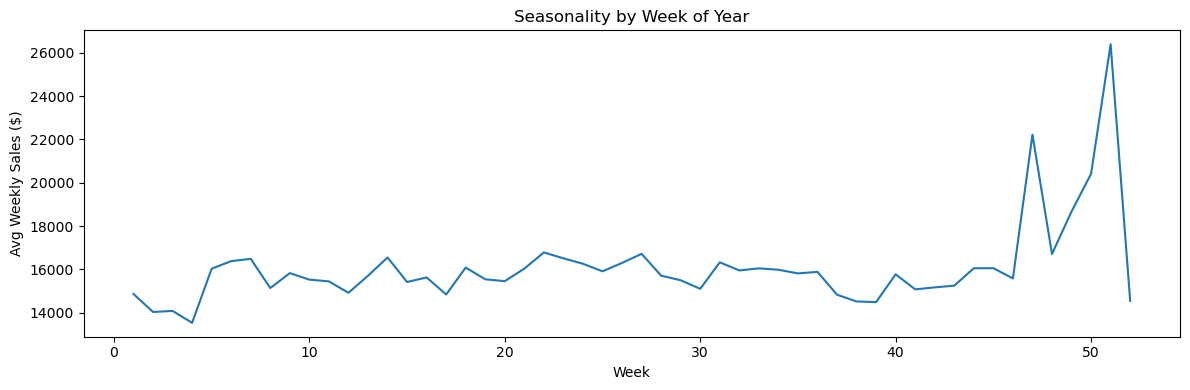

In [9]:
# Average sales by month
monthly_pattern = df.groupby(df["Date"].dt.month)["Weekly_Sales"].mean()
monthly_pattern.plot(kind="bar", figsize=(10, 4))
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Avg Weekly Sales ($)")
plt.tight_layout()
plt.show()

# Average sales by ISO week
df["Week"] = df["Date"].dt.strftime('%U').astype(int)
weekly_pattern = df.groupby("Week")["Weekly_Sales"].mean()
weekly_pattern.plot(figsize=(12, 4))
plt.title("Seasonality by Week of Year")
plt.xlabel("Week")
plt.ylabel("Avg Weekly Sales ($)")
plt.tight_layout()
plt.show()

In [10]:
# Holiday impact
holiday_sales = df.groupby("IsHoliday")["Weekly_Sales"].mean()
print("Average weekly sales by holiday flag:")
print(holiday_sales)

cv = weekly_sales.std() / weekly_sales.mean()
print(f"\nCoefficient of Variation: {cv:.4f}")

Average weekly sales by holiday flag:
IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64

Coefficient of Variation: 0.1156


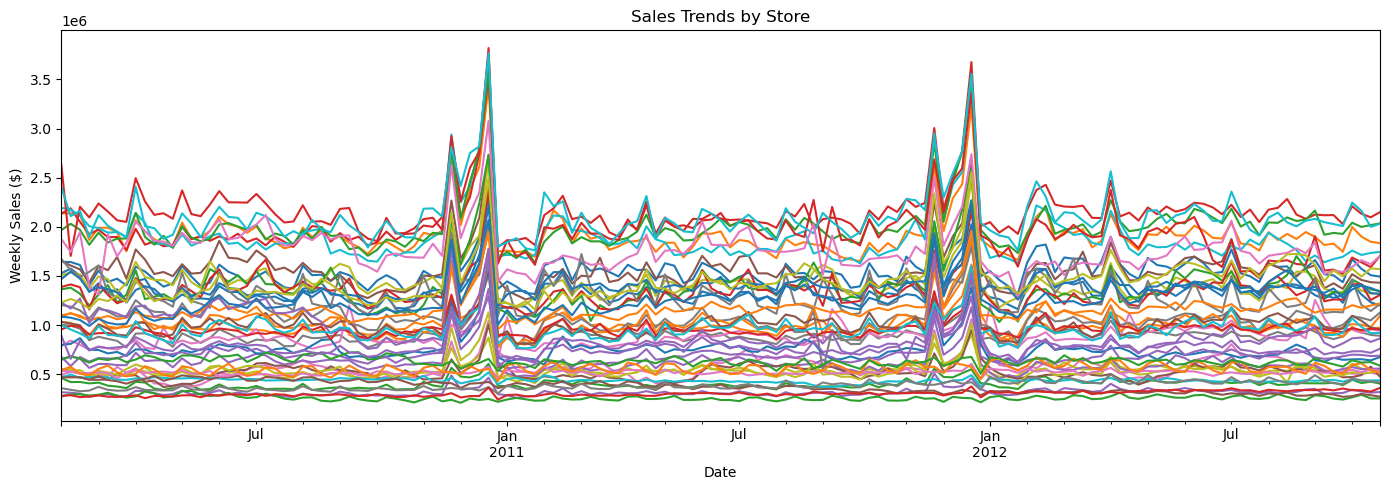

In [11]:
# Per-store sales trends
store_trend = df.groupby(["Date", "Store"])["Weekly_Sales"].sum().unstack()
store_trend.plot(figsize=(14, 5), legend=False)
plt.title("Sales Trends by Store")
plt.xlabel("Date")
plt.ylabel("Weekly Sales ($)")
plt.tight_layout()
plt.show()